# Tópicos em Otimização Irrestrita

### Pacotes importados

In [10]:
using LinearAlgebra
using Printf
using Plots

### Machine epsilon

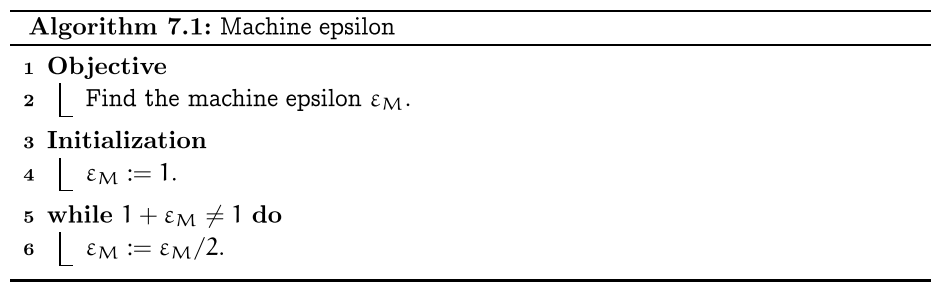

In [1]:
epsilon = 1.0

while 1.0 + epsilon > 1.0
    epsilon = epsilon / 2.0
end

epsilon = epsilon * 2.0

println("Épsilon de máquina = ", epsilon)

Épsilon de máquina = 2.220446049250313e-16


### Newton's method: one variable

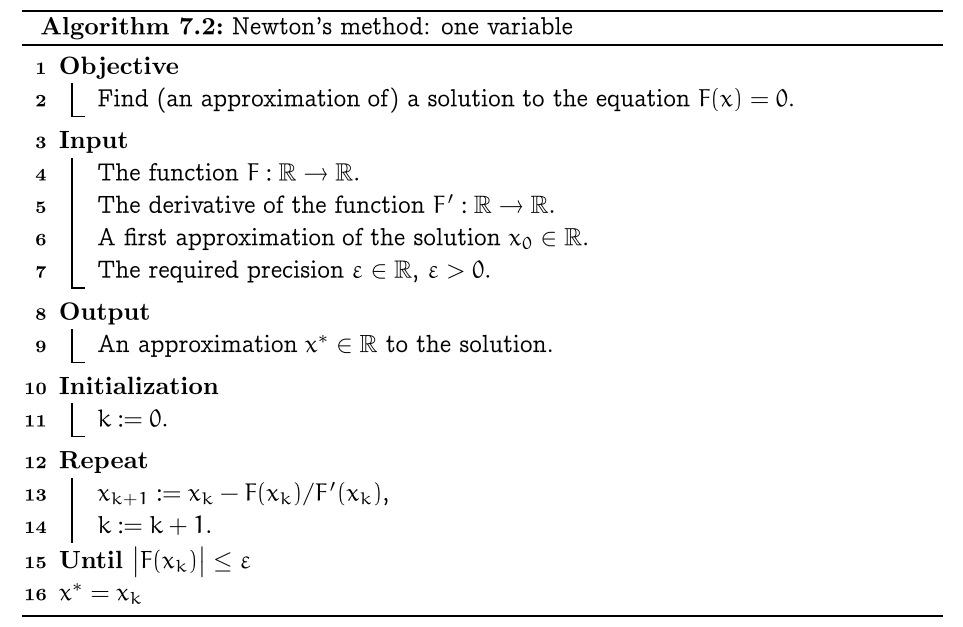

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

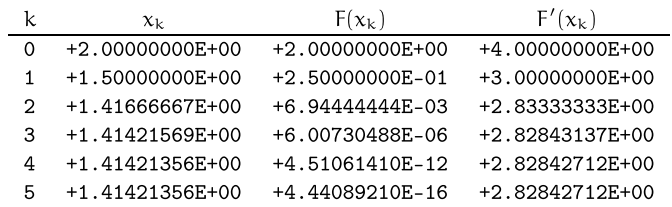

Also plot the graph with the iterations $\times$ the value of F(x).

  k                x_k             F(x_k)            F'(x_k)
  0    +2.00000000E+00    +2.00000000E+00    +4.00000000E+00
  1    +1.50000000E+00    +2.50000000E-01    +3.00000000E+00
  2    +1.41666667E+00    +6.94444444E-03    +2.83333333E+00
  3    +1.41421569E+00    +6.00730488E-06    +2.82843137E+00
  4    +1.41421356E+00    +4.51061410E-12    +2.82842712E+00
  5    +1.41421356E+00    +4.44089210E-16    +2.82842712E+00

Solução aproximada: 1.4142135623730951
F(x): 4.440892098500626e-16


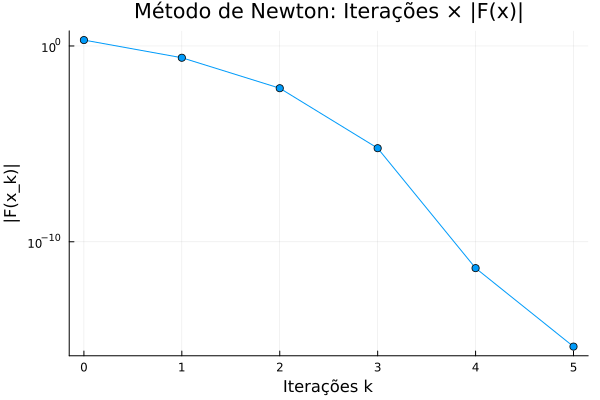

In [6]:
F(x) = x^2 - 2
dF(x) = 2x

x = 2.0
epsilon = 1e-15
k = 0

ks = Int[]
fxs = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x_k", "F(x_k)", "F'(x_k)")

while true
    fx = F(x)
    dfx = dF(x)

    push!(ks, k)
    push!(fxs, fx)

    @printf("%3d %+18.8E %+18.8E %+18.8E\n", k, x, fx, dfx)

    if abs(fx) < epsilon
        break
    end

    x = x - fx / dfx
    k += 1
end

println("\nSolução aproximada: ", x)
println("F(x): ", F(x))

plot(
    ks,
    abs.(fxs),
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "|F(x_k)|",
    title = "Método de Newton: Iterações × |F(x)|",
    legend = false,
    yscale = :log10
)

Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.

  k                x_k             F(x_k)            F'(x_k)
  0    +1.00000000E+00    +1.58529015E-01    +4.59697694E-01
  1    +6.55145072E-01    +4.58707860E-02    +2.07040452E-01
  2    +4.33590368E-01    +1.34587380E-02    +9.25368255E-02
  3    +2.88148401E-01    +3.97094846E-03    +4.12282985E-02
  4    +1.91832312E-01    +1.17439692E-03    +1.83434616E-02
  5    +1.27809668E-01    +3.47684349E-04    +8.15654318E-03
  6    +8.51832336E-02    +1.02980157E-04    +3.62589833E-03
  7    +5.67819528E-02    +3.05077170E-05    +1.61166199E-03
  8    +3.78526008E-02    +9.03867580E-06    +7.16324157E-04
  9    +2.52344645E-02    +2.67804088E-06    +3.18372205E-04
 10    +1.68227978E-02    +7.93482367E-07    +1.41499926E-04

Solução aproximada: 0.011215145640462639
F(x): 2.3510440783081066e-7


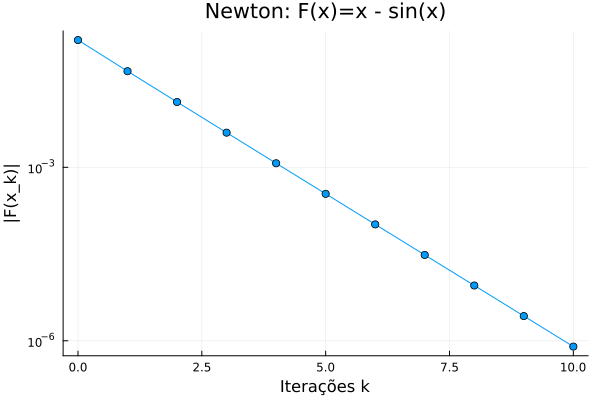

In [8]:
F(x) = x - sin(x)
dF(x) = 1 - cos(x)

x = 1.0
epsilon = 1e-15
k = 0
maxiter = 10

ks = Int[]
fxs = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x_k", "F(x_k)", "F'(x_k)")

while k <= maxiter
    fx = F(x)
    dfx = dF(x)

    push!(ks, k)
    push!(fxs, fx)

    @printf("%3d %+18.8E %+18.8E %+18.8E\n", k, x, fx, dfx)

    if abs(fx) < epsilon
        break
    end

    x = x - fx / dfx
    k += 1
end

println("\nSolução aproximada: ", x)
println("F(x): ", F(x))

plot(
    ks,
    abs.(fxs),
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "|F(x_k)|",
    title = "Newton: F(x)=x - sin(x)",
    legend = false,
    yscale = :log10
)

Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.

  k                x_k             F(x_k)            F'(x_k)
  0    +1.50000000E+00    +9.82793723E-01    +3.07692308E-01
  1    -1.69407960E+00    -1.03754636E+00    +2.58404230E-01
  2    +2.32112696E+00    +1.16400204E+00    +1.56552578E-01
  3    -5.11408784E+00    -1.37769453E+00    +3.68271300E-02
  4    +3.22956839E+01    +1.53984233E+00    +9.57844131E-04
  5    -1.57531695E+03    -1.57016153E+00    +4.02961851E-07
  6    +3.89497601E+06    +1.57079607E+00    +6.59159364E-14
  7    -2.38302890E+13    -1.57079633E+00    +1.76092712E-27
  8    +8.92028016E+26    +1.57079633E+00    +1.25673298E-54
  9    -1.24990460E+54    -1.57079633E+00   +6.40097701E-109
 10   +2.45399464E+108    +1.57079633E+00   +1.66055315E-217

Solução aproximada: -9.459476350342202e216
F(x): -1.5707963267948966


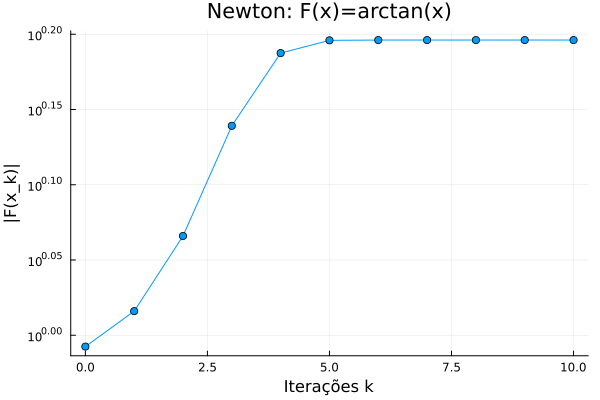

In [9]:
F(x) = atan(x)
dF(x) = 1 / (1 + x^2)

x = 1.5
epsilon = 1e-15
k = 0
maxiter = 10

ks = Int[]
fxs = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x_k", "F(x_k)", "F'(x_k)")

while k <= maxiter
    fx = F(x)
    dfx = dF(x)

    push!(ks, k)
    push!(fxs, fx)

    @printf("%3d %+18.8E %+18.8E %+18.8E\n", k, x, fx, dfx)

    if abs(fx) < epsilon
        break
    end

    x = x - fx / dfx
    k += 1
end

println("\nSolução aproximada: ", x)
println("F(x): ", F(x))

plot(
    ks,
    abs.(fxs),
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "|F(x_k)|",
    title = "Newton: F(x)=arctan(x)",
    legend = false,
    yscale = :log10
)

### Algorithm 7.3: Newton's method: $n$ variables

''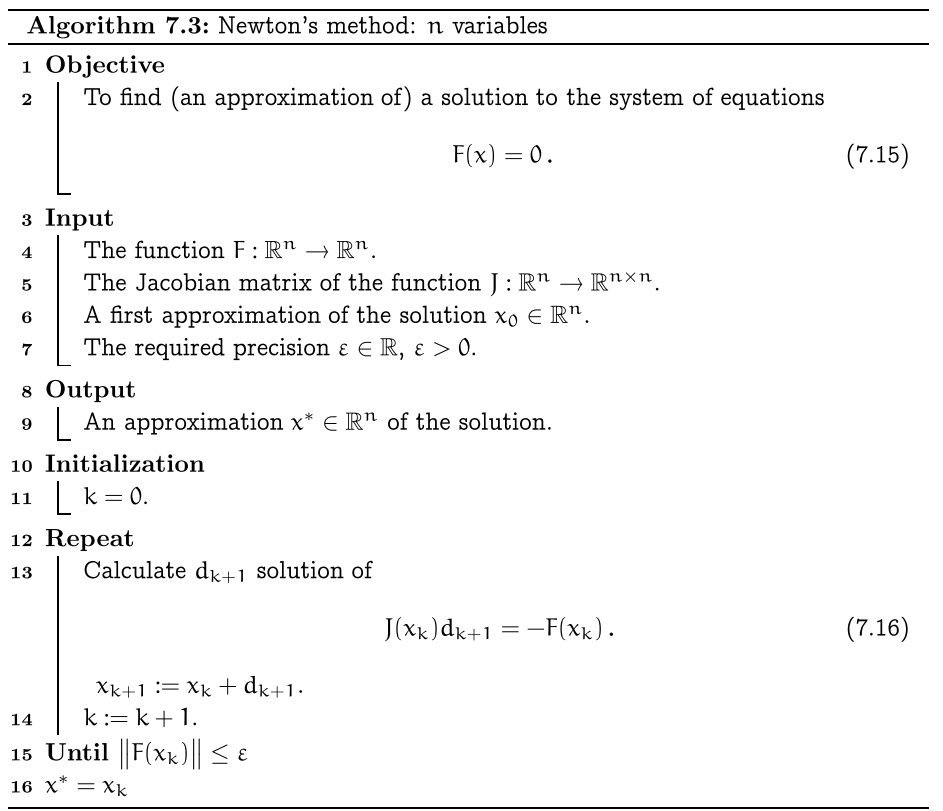''

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

  k                 x1                 x2           ||F(x)||
  0  +1.0000000000E+00  +1.0000000000E+00  +3.4572376895E+00
  1  +1.5235921364E-01  +1.1952815727E+00  +1.1547087094E+00
  2  -1.0837680936E-02  +1.0361111673E+00  +1.1404255765E-01
  3  -8.8966460147E-04  +1.0015353165E+00  +3.9423297592E-03
  4  -1.3700887510E-06  +1.0000029387E+00  +8.0799855603E-06
  5  -5.5384175017E-12  +1.0000000000E+00  +2.8831122570E-11
  6  -6.9943466223E-17  +1.0000000000E+00  +4.4408920985E-16

Solução aproximada:
x* = [-6.994346622311609e-17, 1.0000000000000002]
F(x*) = [0.0, 4.440892098500626e-16]
||F(x*)|| = 4.440892098500626e-16


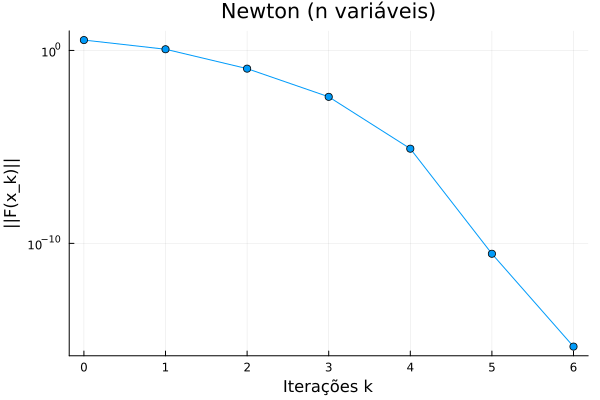

In [11]:

# Definição da função F(x)
F(x) = [
    (x[1] + 1)^2 + x[2]^2 - 2
    exp(x[1]) + x[2]^3 - 2
]

# Jacobiana J(x)
J(x) = [
    2(x[1] + 1)   2x[2]
    exp(x[1])     3x[2]^2
]

# Dados iniciais
x = [1.0, 1.0]
epsilon = 1e-15
k = 0
maxiter = 50

# Para gráfico
ks = Int[]
norms = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||F(x)||")

# Algoritmo 7.3
while k <= maxiter

    Fx = F(x)
    Jx = J(x)
    normFx = norm(Fx)

    push!(ks, k)
    push!(norms, normFx)

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normFx)

    if normFx <= epsilon
        break
    end

    # Resolve: J(x_k) d = -F(x_k)
    d = Jx \ (-Fx)

    # Atualiza: x_{k+1} = x_k + d
    x = x + d

    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("||F(x*)|| = ", norm(F(x)))

# Gráfico
plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||F(x_k)||",
    title = "Newton (n variáveis)",
    legend = false,
    yscale = :log10
)

Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

  k                 x1                 x2           ||F(x)||
  0  +1.0000000000E+00  +1.0000000000E+00  +3.6055512755E+00
  1  +6.6666666667E-01  +5.0000000000E-01  +1.3199641602E+00
  2  +5.7884444444E-01  -1.2746666667E-01  +8.4373632059E-01
  3  +1.2469639816E+00  +3.1357842515E-01  +1.5416110766E+00
  4  +1.0089481978E+00  +1.1367796515E-01  +3.4590469075E-01
  5  +9.8786804598E-01  +3.8368436429E-03  +3.7711505057E-02
  6  +1.0001341442E+00  -9.5322185096E-05  +4.9375529428E-04
  7  +1.0000000089E+00  -2.5568132903E-08  +8.1228435716E-08
  8  +1.0000000000E+00  -4.5562445194E-16  +2.1544562866E-15
  9  +1.0000000000E+00  +4.9303806576E-31  +1.4791141973E-30

Solução aproximada:
x* = [1.0, 4.930380657631324e-31]
F(x*) = [0.0, -1.4791141972893971e-30]
||F(x*)|| = 1.4791141972893971e-30


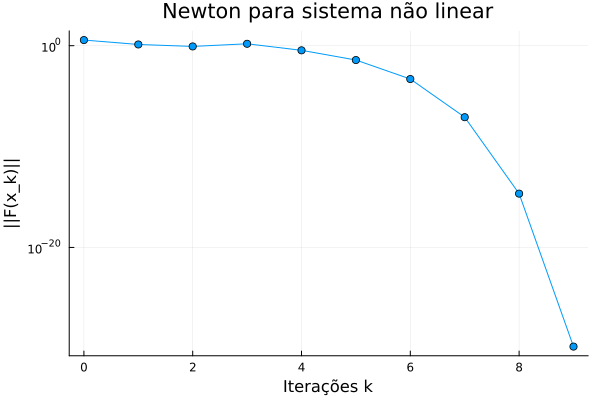

In [13]:
# Função F(x)
F(x) = [
    x[1]^3 - 3*x[1]*x[2]^2 - 1
    x[2]^3 - 3*x[1]^2*x[2]
]

# Jacobiana J(x)
J(x) = [
    3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2]
    -6*x[1]*x[2]            3*x[2]^2 - 3*x[1]^2
]

# Dados iniciais
x = [1.0, 1.0]
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||F(x)||")

while k <= maxiter
    Fx = F(x)
    Jx = J(x)
    normFx = norm(Fx)

    push!(ks, k)
    push!(norms, normFx)

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normFx)

    if normFx <= epsilon
        break
    end

    # Resolve J(x_k)d = -F(x_k)
    d = Jx \ (-Fx)

    # Atualiza x
    x = x + d

    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("||F(x*)|| = ", norm(F(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||F(x_k)||",
    title = "Newton para sistema não linear",
    legend = false,
    yscale = :log10
)

Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

  k                 x1                 x2           ||F(x)||
  0  -1.0000000000E+00  -1.0000000000E+00  +2.2360679775E+00
  1  -6.6666666667E-01  -8.3333333333E-01  +5.4039895972E-01
  2  -5.0869191619E-01  -8.4109987441E-01  +7.7840426360E-02
  3  -4.9932999564E-01  -8.6626917179E-01  +2.1386503575E-03
  4  -4.9999991137E-01  -8.6602490316E-01  +1.5252366691E-06
  5  -5.0000000000E-01  -8.6602540378E-01  +7.7529900909E-13
  6  -5.0000000000E-01  -8.6602540378E-01  +2.4825341532E-16

Solução aproximada:
x* = [-0.49999999999999994, -0.8660254037844386]
F(x*) = [-2.220446049250313e-16, -1.1102230246251565e-16]
||F(x*)|| = 2.482534153247273e-16


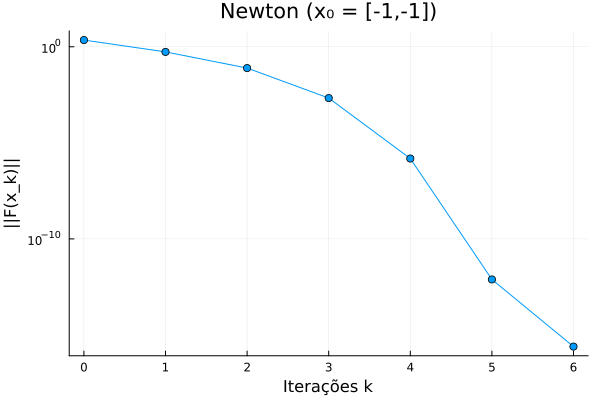

In [15]:
# Função
F(x) = [
    x[1]^3 - 3*x[1]*x[2]^2 - 1
    x[2]^3 - 3*x[1]^2*x[2]
]

# Jacobiana
J(x) = [
    3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2]
    -6*x[1]*x[2]            3*x[2]^2 - 3*x[1]^2
]

# Condição inicial
x = [-1.0, -1.0]
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||F(x)||")

while k <= maxiter
    Fx = F(x)
    Jx = J(x)
    normFx = norm(Fx)

    push!(ks, k)
    push!(norms, normFx)

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normFx)

    if normFx <= epsilon
        break
    end

    # Resolve J d = -F
    d = Jx \ (-Fx)

    x = x + d
    k += 1
end

println("\nSolução aproximada:")
println("x* = ", x)
println("F(x*) = ", F(x))
println("||F(x*)|| = ", norm(F(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||F(x_k)||",
    title = "Newton (x₀ = [-1,-1])",
    legend = false,
    yscale = :log10
)

Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

  k                 x1                 x2           ||F(x)||
  0  +0.0000000000E+00  +1.0000000000E+00  +1.4142135624E+00
  1  -3.3333333333E-01  +6.6666666667E-01  +5.9720427765E-01
  2  -5.8222222222E-01  +9.2444444444E-01  +3.3128125366E-01
  3  -5.0879080329E-01  +8.6816551189E-01  +2.7312827581E-02
  4  -5.0006873907E-01  +8.6598221869E-01  +2.4353592068E-04
  5  -4.9999999629E-01  +8.6602539834E-01  +1.9770114367E-08
  6  -5.0000000000E-01  +8.6602540378E-01  +4.9650683065E-16

Resultado final:
x = [-0.5000000000000001, 0.8660254037844387]
F(x) = [4.440892098500626e-16, -2.220446049250313e-16]
||F(x)|| = 4.965068306494546e-16


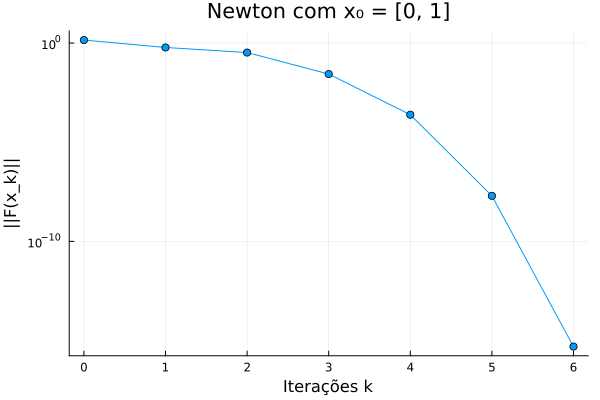

In [16]:
F(x) = [
    x[1]^3 - 3*x[1]*x[2]^2 - 1
    x[2]^3 - 3*x[1]^2*x[2]
]

J(x) = [
    3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2]
    -6*x[1]*x[2]            3*x[2]^2 - 3*x[1]^2
]

x = [0.0, 1.0]
epsilon = 1e-15
k = 0
maxiter = 50

ks = Int[]
norms = Float64[]

@printf("%3s %18s %18s %18s\n", "k", "x1", "x2", "||F(x)||")

while k <= maxiter
    Fx = F(x)
    Jx = J(x)
    normFx = norm(Fx)

    push!(ks, k)
    push!(norms, normFx)

    @printf("%3d %+18.10E %+18.10E %+18.10E\n", k, x[1], x[2], normFx)

    if normFx <= epsilon
        break
    end

    if abs(det(Jx)) < 1e-12
        println("\nJacobiana singular ou quase singular. Método interrompido.")
        break
    end

    d = Jx \ (-Fx)

    x = x + d
    k += 1
end

println("\nResultado final:")
println("x = ", x)
println("F(x) = ", F(x))
println("||F(x)|| = ", norm(F(x)))

plot(
    ks,
    norms,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "||F(x_k)||",
    title = "Newton com x₀ = [0, 1]",
    legend = false,
    yscale = :log10
)